<img src="./logo_UNSAM.jpg" align="right" width="150" /> 

#### Análisis y Procesamiento de Señales

# Trabajo Práctico Nº2
#### Manuel Helas
En este trabajp se simulara un conversot analogico-digital o ADC.
se analizara el proceso de cuantizacion de la señal resultante con ditintos valores y se estudiara el interaccion entre el ruido analogico y ruido digital

### Ejercicio 1:

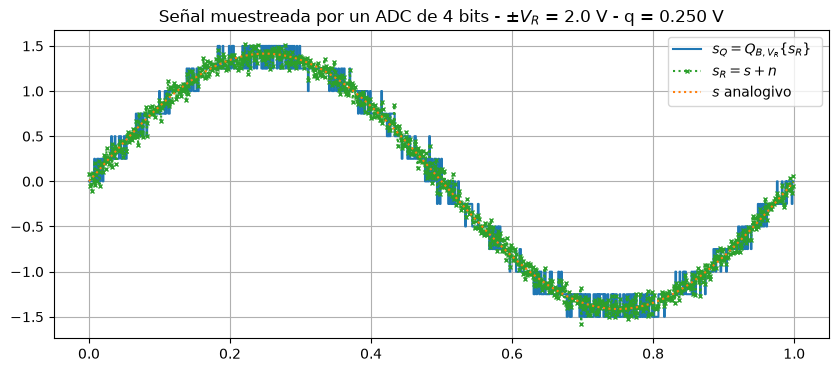

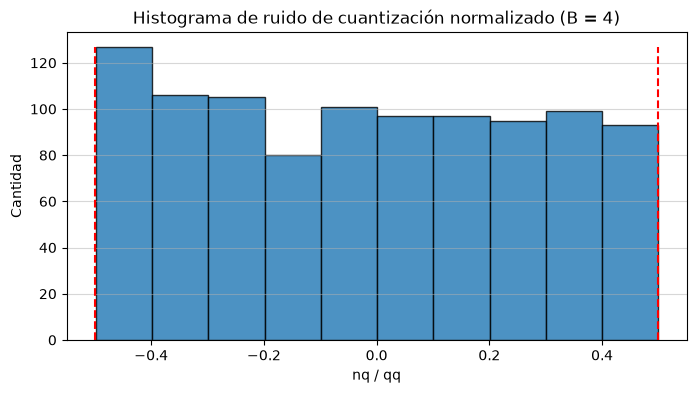

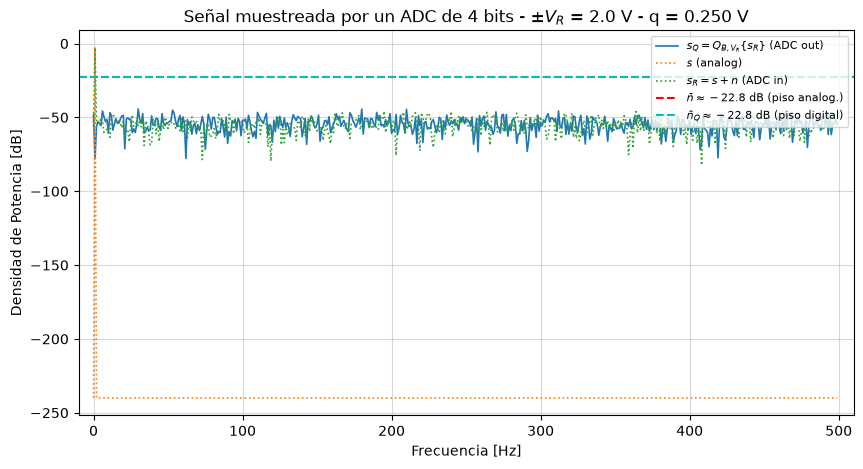

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats

plt.close("all")

fs = 1000  
N = 1000  


vref = 2  
B = 4  
kn = 1  
ff = fs / N  
dc = 0  
ph = 0  
vmax = np.sqrt(2)



def mi_funcion_sen(vmax=1, dc=0, ff=1, ph=0, nn=N, fs=fs):
  tt = np.arange(start=0, stop=nn / fs, step=1 / fs)
  xx = (vmax * np.sin(2 * np.pi * ff * tt + ph)) + dc
  return (tt, xx)


tt, xx = mi_funcion_sen(vmax=vmax, dc=dc, ff=ff, ph=ph, nn=N, fs=fs)
pot_senal = np.var(xx)


qq = (2 * vref) / (2**B)
pot_r = kn * (qq**2) / 12
SNR = 10 * np.log10(pot_senal / pot_r)



xx_rand = np.random.normal(loc=0.0, scale=np.sqrt(pot_r), size=N)


xxr = xx + xx_rand



xx_q = np.round(xxr / qq) * qq
nq = xx_q - xxr
ruido_norm = nq / qq

plt.figure(figsize=(10, 4))
plt.step(
    tt,
    xx_q,
    where="mid",
    label=("$s_Q = Q_{{B,V_R}}\{{s_R\}}$ "),
    color="tab:blue",
)


plt.plot(
    tt,
    xxr,
    ":x",
    label="$s_R = s + n$ ",
    color="tab:green",
    markersize=3,
)
plt.plot(tt, xx, ":", label="$s$ analogivo", color="tab:orange")
plt.title(
    f"Señal muestreada por un ADC de {B} bits - $\\pm V_R$ ="
    f" {vref:.1f} V - q = {qq:.3f} V"
)
plt.grid()
plt.legend()
plt.show()


plt.figure(figsize=(8, 4))
count, bins, ignored = plt.hist(
    ruido_norm, bins=10, edgecolor="black", alpha=0.8
)
plt.vlines(
    x=[-0.5, 0.5],
    ymin=0,
    ymax=max(count),
    color="red",
    linestyle="--",
    linewidth=1.5,
)
plt.title(f"Histograma de ruido de cuantización normalizado (B = {B})")
plt.xlabel("nq / qq")
plt.ylabel("Cantidad")
plt.grid(axis="y", alpha=0.5)




N_fft = len(xx)
frec = np.arange(0, fs / 2, fs / N_fft)  


fft_s = np.fft.fft(xx) / N_fft
psd_s = 20 * np.log10(np.abs(fft_s[: int(N_fft / 2)]) + 1e-12)


fft_xxr = np.fft.fft(xxr) / N_fft
psd_xxr = 20 * np.log10(np.abs(fft_xxr[: int(N_fft / 2)]) + 1e-12)


fft_q = np.fft.fft(nq) / N_fft
psd_q = 20 * np.log10(np.abs(fft_q[: int(N_fft / 2)]) + 1e-12)


piso_analog_dB = 10 * np.log10(pot_r)
piso_digital_dB = 10 * np.log10((qq**2) / 12)

plt.figure(figsize=(10, 5))

plt.plot(
    frec,
    psd_q,
    label="$s_Q = Q_{B,V_R}\{s_R\}$ (ADC out)",
    color="tab:blue",
    linewidth=1.2,
)

plt.plot(
    frec, psd_s, ":", label="$s$ (analog)", color="tab:orange", linewidth=1.2
)
plt.plot(
    frec,
    psd_xxr,
    ":",
    label="$s_R = s + n$ (ADC in)",
    color="tab:green",
    linewidth=1.2,
)


plt.axhline(
    y=piso_analog_dB,
    color="red",
    linestyle="--",
    label=f"$\\bar{{n}} \\approx {piso_analog_dB:.1f}$ dB (piso analog.)",
)
plt.axhline(
    y=piso_digital_dB,
    color="c",
    linestyle="--",
    label=f"$\\bar{{n}}_Q \\approx {piso_digital_dB:.1f}$ dB (piso digital)",
)

plt.title(
    f"Señal muestreada por un ADC de {B} bits - $\\pm V_R$ ="
    f" {vref:.1f} V - q = {qq:.3f} V"
)
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Densidad de Potencia [dB]")
plt.grid(True, alpha=0.5)
plt.legend(loc="upper right", fontsize=8)
plt.xlim(-10, fs / 2 + 10)


plt.show()



De estos graficos se pueden sacar distintras concluciones:
Primero se ve el escalonamiento de un ADC de baja resolucion. Se ve como le funcion de entrada Sr tiene cierta suavidad mientras que Sq va dando saltos bruscos, esto se debe a que nuestro adc con un rango analogico de 4 volts, se divide en solamente 16 niveles de 0,25V cada unos entonces muchos valores intermedios quedan "atrapados" entre esos valores lo que hace que al tener que si o si elegir uno de los niveles, la señal tenga poca resolucion y de saltos bruscos.
Luego se observa que cuando K = 1 la potencia de ruido externo es igual a la potencia de ruido de cuantizacion por lo cual el piso de ruido analogico y el piso de ruido digital se superponen en el grafico.



### Ejercicio 2:

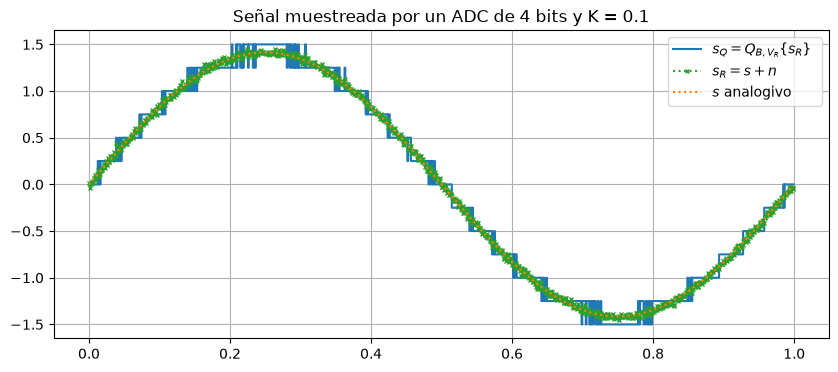

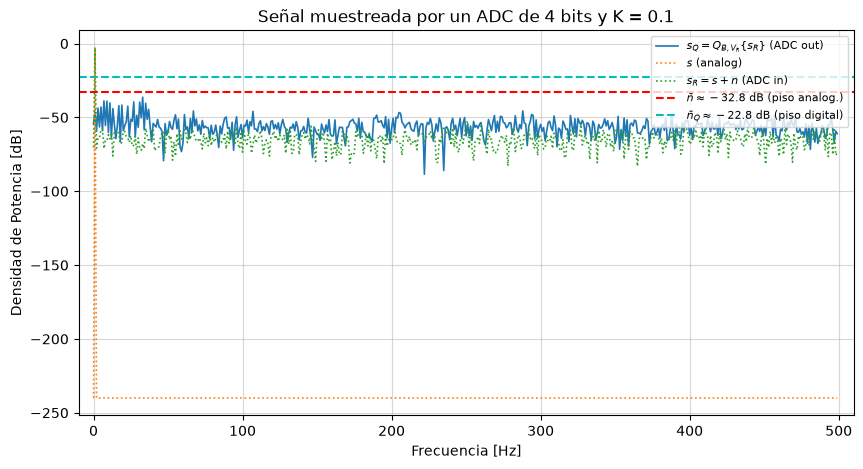

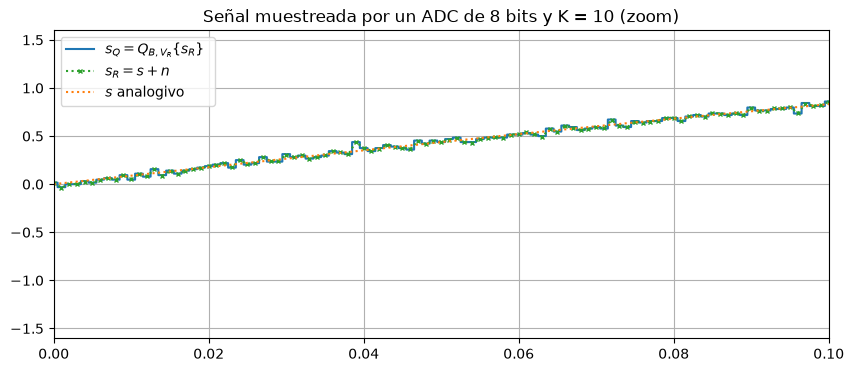

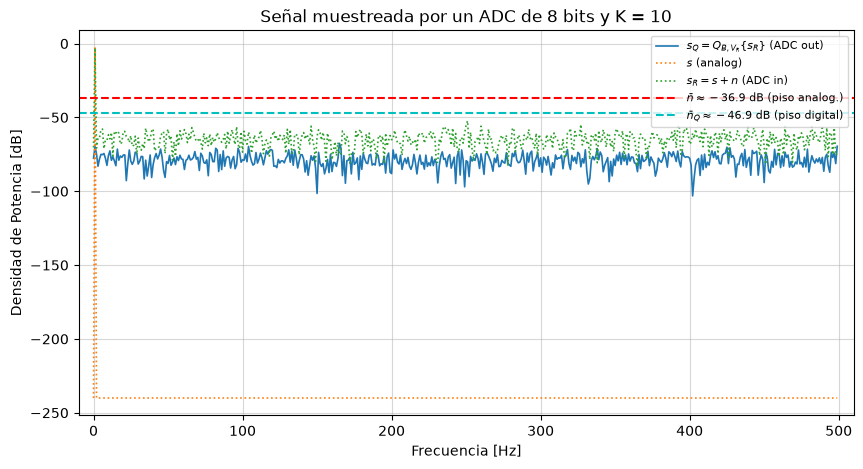

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats

plt.close("all")

fs = 1000  
N = 1000  


vref = 2  
B = 4
kn = 1/10
ff = fs / N  
dc = 0  
ph = 0  
vmax = np.sqrt(2)



def mi_funcion_sen(vmax=1, dc=0, ff=1, ph=0, nn=N, fs=fs):
  tt = np.arange(start=0, stop=nn / fs, step=1 / fs)
  xx = (vmax * np.sin(2 * np.pi * ff * tt + ph)) + dc
  return (tt, xx)


tt, xx = mi_funcion_sen(vmax=vmax, dc=dc, ff=ff, ph=ph, nn=N, fs=fs)
pot_senal = np.var(xx)


qq = (2 * vref) / (2**B)
pot_r = kn * (qq**2) / 12
SNR = 10 * np.log10(pot_senal / pot_r)



xx_rand = np.random.normal(loc=0.0, scale=np.sqrt(pot_r), size=N)


xxr = xx + xx_rand



xx_q = np.round(xxr / qq) * qq
nq = xx_q - xxr
ruido_norm = nq / qq

plt.figure(figsize=(10, 4))
plt.step(
    tt,
    xx_q,
    where="mid",
    label=("$s_Q = Q_{{B,V_R}}\{{s_R\}}$ "),
    color="tab:blue",
)


plt.plot(
    tt,
    xxr,
    ":x",
    label="$s_R = s + n$ ",
    color="tab:green",
    markersize=3,
)
plt.plot(tt, xx, ":", label="$s$ analogivo", color="tab:orange")
plt.title(
    f"Señal muestreada por un ADC de {B} bits y K = {kn}"
    
)
plt.grid()
plt.legend()
plt.show()


N_fft = len(xx)
frec = np.arange(0, fs / 2, fs / N_fft)  


fft_s = np.fft.fft(xx) / N_fft
psd_s = 20 * np.log10(np.abs(fft_s[: int(N_fft / 2)]) + 1e-12)


fft_xxr = np.fft.fft(xxr) / N_fft
psd_xxr = 20 * np.log10(np.abs(fft_xxr[: int(N_fft / 2)]) + 1e-12)


fft_q = np.fft.fft(nq) / N_fft
psd_q = 20 * np.log10(np.abs(fft_q[: int(N_fft / 2)]) + 1e-12)


piso_analog_dB = 10 * np.log10(pot_r)
piso_digital_dB = 10 * np.log10((qq**2) / 12)

plt.figure(figsize=(10, 5))

plt.plot(
    frec,
    psd_q,
    label="$s_Q = Q_{B,V_R}\{s_R\}$ (ADC out)",
    color="tab:blue",
    linewidth=1.2,
)

plt.plot(
    frec, psd_s, ":", label="$s$ (analog)", color="tab:orange", linewidth=1.2
)
plt.plot(
    frec,
    psd_xxr,
    ":",
    label="$s_R = s + n$ (ADC in)",
    color="tab:green",
    linewidth=1.2,
)


plt.axhline(
    y=piso_analog_dB,
    color="red",
    linestyle="--",
    label=f"$\\bar{{n}} \\approx {piso_analog_dB:.1f}$ dB (piso analog.)",
)
plt.axhline(
    y=piso_digital_dB,
    color="c",
    linestyle="--",
    label=f"$\\bar{{n}}_Q \\approx {piso_digital_dB:.1f}$ dB (piso digital)",
)

plt.title(
    f"Señal muestreada por un ADC de {B} bits y K = {kn}"
)
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Densidad de Potencia [dB]")
plt.grid(True, alpha=0.5)
plt.legend(loc="upper right", fontsize=8)
plt.xlim(-10, fs / 2 + 10)
plt.show()


#SEGUNDA CONFIGURACION
kn = 10
B = 8
qq = (2 * vref) / (2**B)
pot_r = kn * (qq**2) / 12
SNR = 10 * np.log10(pot_senal / pot_r)
xx_q = np.round(xxr / qq) * qq
nq = xx_q - xxr
ruido_norm = nq / qq

plt.figure(figsize=(10, 4))
plt.step(
    tt,
    xx_q,
    where="mid",
    label=("$s_Q = Q_{{B,V_R}}\{{s_R\}}$ "),
    color="tab:blue",
)


plt.plot(
    tt,
    xxr,
    ":x",
    label="$s_R = s + n$ ",
    color="tab:green",
    markersize=3,
)
plt.plot(tt, xx, ":", label="$s$ analogivo", color="tab:orange")
plt.title(
    f"Señal muestreada por un ADC de {B} bits y K = {kn} (zoom)"
    
)
plt.xlim(0, 0.1)
plt.grid()
plt.legend()
plt.show()

N_fft = len(xx)
frec = np.arange(0, fs / 2, fs / N_fft)  


fft_s = np.fft.fft(xx) / N_fft
psd_s = 20 * np.log10(np.abs(fft_s[: int(N_fft / 2)]) + 1e-12)


fft_xxr = np.fft.fft(xxr) / N_fft
psd_xxr = 20 * np.log10(np.abs(fft_xxr[: int(N_fft / 2)]) + 1e-12)


fft_q = np.fft.fft(nq) / N_fft
psd_q = 20 * np.log10(np.abs(fft_q[: int(N_fft / 2)]) + 1e-12)


piso_analog_dB = 10 * np.log10(pot_r)
piso_digital_dB = 10 * np.log10((qq**2) / 12)

plt.figure(figsize=(10, 5))

plt.plot(
    frec,
    psd_q,
    label="$s_Q = Q_{B,V_R}\{s_R\}$ (ADC out)",
    color="tab:blue",
    linewidth=1.2,
)

plt.plot(
    frec, psd_s, ":", label="$s$ (analog)", color="tab:orange", linewidth=1.2
)
plt.plot(
    frec,
    psd_xxr,
    ":",
    label="$s_R = s + n$ (ADC in)",
    color="tab:green",
    linewidth=1.2,
)


plt.axhline(
    y=piso_analog_dB,
    color="red",
    linestyle="--",
    label=f"$\\bar{{n}} \\approx {piso_analog_dB:.1f}$ dB (piso analog.)",
)
plt.axhline(
    y=piso_digital_dB,
    color="c",
    linestyle="--",
    label=f"$\\bar{{n}}_Q \\approx {piso_digital_dB:.1f}$ dB (piso digital)",
)

plt.title(
    f"Señal muestreada por un ADC de {B} bits y K = {kn}"
)
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Densidad de Potencia [dB]")
plt.grid(True, alpha=0.5)
plt.legend(loc="upper right", fontsize=8)
plt.xlim(-10, fs / 2 + 10)
plt.show()


Se puden ver rapidamente las diferencias y coincide con lo hablado anteriromente, como con 8 bits a diferencia de 4 se puede ver como la señal de la salida del ADC se vuelve mas suave ya que va dando saltos mucho menos bruscos.
Tambien se ve claramente como al aumentar K, nuestro ruido externo se vuelve muchisimo mayor que nuestro ruido digital generado por la cantidad de bits con la que tranajamos y en este ejemplo que aparte tenemos 8 bits y k = 10 se ve claramente esa separacion mientras que con 4 bits y K = 1/10 lo que mas ruido genera es el ruido de cuantizacion de los 4 bits
    